In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from objectives import m_elbo  # or iwae, dreg, etc.
from models import VAE_gpi_stn  
import os
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import r2_score


In [17]:
def train_mmvae_model(gpi_tensor, stn_tensor, args, num_epochs=50, batch_size=8, model_save_path="mmvae_model.pt"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = TensorDataset(gpi_tensor, stn_tensor)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    model = VAE_gpi_stn(args).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0
        for gpi_batch, stn_batch in train_loader:
            gpi_batch, stn_batch = gpi_batch.to(device), stn_batch.to(device)
            data = (gpi_batch, stn_batch)
            optimizer.zero_grad()
            loss = -m_elbo(model, data, K=5)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for gpi_batch, stn_batch in val_loader:
                gpi_batch, stn_batch = gpi_batch.to(device), stn_batch.to(device)
                data = (gpi_batch, stn_batch)
                loss = -m_elbo(model, data, K=5)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch}/{num_epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    torch.save(model.state_dict(), model_save_path)
    print(f"✅ Final model saved to {model_save_path}")

    return model, val_loader, device


In [ ]:

def get_mmvae_recon_mse_r2(model, gpi_test, stn_test, device, subject_id=None, side=None):
    model.eval()
    records = []

    for i in range(gpi_test.shape[0]):
        gpi = gpi_test[i:i+1].to(device)
        stn = stn_test[i:i+1].to(device)

        with torch.no_grad():
            qz_gpi, _, _ = model.vaes[0](gpi)  # GPi encoder
            qz_stn, _, _ = model.vaes[1](stn)  # STN encoder

            z_gpi = qz_gpi.rsample()
            z_stn = qz_stn.rsample()

            dec_gpi_from_gpi = model.vaes[0].dec(z_gpi)[0]
            dec_stn_from_stn = model.vaes[1].dec(z_stn)[0]
            dec_gpi_from_stn = model.vaes[0].dec(z_stn)[0]
            dec_stn_from_gpi = model.vaes[1].dec(z_gpi)[0]

            outputs = {
                "gpi_full": dec_gpi_from_gpi,
                "gpi_full_stn": dec_gpi_from_stn,
                "stn_full": dec_stn_from_stn,
                "stn_full_gpi": dec_stn_from_gpi,
            }

            targets = {
                "gpi": gpi,
                "stn": stn,
            }

            for key, output in outputs.items():
                region = key.split("_")[0]
                target = targets[region]
                mse = F.mse_loss(output, target, reduction='mean').item()
                r2 = r2_score(target.cpu().numpy().flatten(), output.cpu().numpy().flatten())
                records.append({
                    "subject": subject_id,
                    "side": side,
                    "sample": i,
                    "condition": key,
                    "mse": mse,
                    "r2": r2
                })

    return pd.DataFrame(records)


In [19]:

def plot_reconstructions(model, gpi_tensor, stn_tensor, device, num_samples=4,runPath="./viz", modality='gpi'):
    model.eval()
    with torch.no_grad():
        # Select subset
        gpi_batch = gpi_tensor[:num_samples].to(device)
        stn_batch = stn_tensor[:num_samples].to(device)
        data = (gpi_batch, stn_batch)

        # Run reconstruction
        recon = model.reconstruct(data, runPath, epoch=0)

    if modality == 'gpi':
        orig = gpi_batch.cpu().numpy()
        recons = recon[0][0].cpu().numpy()  # GPi from GPi
        label = 'GPi'
    else:
        orig = stn_batch.cpu().numpy()
        recons = recon[1][1].cpu().numpy()  # STN from STN
        label = 'STN'

    # Plot
    for i in range(num_samples):
        fig, axs = plt.subplots(2, 1, figsize=(12, 4))
        axs[0].set_title(f"{label} Original - Sample {i}")
        axs[1].set_title(f"{label} Reconstructed - Sample {i}")
        
        axs[0].imshow(orig[i], aspect='auto', origin='lower', cmap='viridis')
        axs[1].imshow(recons[i], aspect='auto', origin='lower', cmap='viridis')
        
        for ax in axs:
            ax.set_ylabel("Channel")
            ax.set_xlabel("Time")

        plt.tight_layout()
        plt.show()


def plot_timeseries_reconstruction(model, gpi_tensor, stn_tensor, device,
                                   modality='gpi', sample_idx=0, channels_to_plot=[0, 1],
                                   runPath="./viz", epoch=0):
    """
    Plot real vs reconstructed time series for selected channels of one sample.

    Parameters:
    - model: trained MMVAE model
    - gpi_tensor, stn_tensor: torch tensors of shape [N, C, T]
    - modality: 'gpi' or 'stn'
    - sample_idx: index of the sample to visualize
    - channels_to_plot: list of channel indices to plot
    - runPath, epoch: for internal reconstruct() saving
    """
    model.eval()
    with torch.no_grad():
        gpi_batch = gpi_tensor[[sample_idx]].to(device)
        stn_batch = stn_tensor[[sample_idx]].to(device)
        data = (gpi_batch, stn_batch)
        recon = model.reconstruct(data, runPath, epoch)

    if modality == 'gpi':
        original = gpi_batch.cpu().squeeze().numpy()  # shape: [C, T]
        reconstructed = recon[0][0].cpu().squeeze().numpy()  # shape: [C, T]
        label = "GPi"
    else:
        original = stn_batch.cpu().squeeze().numpy()
        reconstructed = recon[1][1].cpu().squeeze().numpy()
        label = "STN"

    # Plot selected channels
    T = original.shape[-1]
    time = range(T)
    num_channels = len(channels_to_plot)
    fig, axs = plt.subplots(num_channels, 1, figsize=(12, 3 * num_channels), sharex=True)

    for i, ch in enumerate(channels_to_plot):
        ax = axs[i] if num_channels > 1 else axs
        ax.plot(time, original[ch], label='Original', color='black')
        ax.plot(time, reconstructed[ch], label='Reconstructed', color='orange', linestyle='--')
        ax.set_title(f'{label} - Channel {ch}')
        ax.set_ylabel('Amplitude')
        ax.legend(loc='upper right')

    axs[-1].set_xlabel('Time')
    plt.tight_layout()
    plt.show()

def plot_stn_reconstruction_timeseries(model, stn_tensor, device, sample_idx=0, channels_to_plot=[0, 1]):
    model.eval()
    with torch.no_grad():
        input_batch = stn_tensor[sample_idx:sample_idx+1].to(device)  # shape: (1, C, T)
        recon = model.reconstruct(input_batch, runPath="./", epoch=0)  # returns (1, C, T)
    
    original = input_batch.cpu().squeeze().numpy()  # shape: (C, T)
    recon = recon.squeeze().cpu().numpy()  # shape: (C, T)

    # Plot selected channels
    for ch in channels_to_plot:
        plt.figure(figsize=(10, 2.5))
        plt.plot(original[ch], label="Original", linewidth=2)
        plt.plot(recon[ch], label="Reconstructed", linestyle="--", linewidth=2)
        plt.title(f"STN - Channel {ch} | Sample {sample_idx}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [13]:

subject_list = ["s508", "s513","s514", "s515","s518","s519","s520","s521","s523"]  # left side
# subject_list = ["s508","s514", "s515","s517","s519","s520","s521","s523"]  # right side

# subject_list = ["s508"]
data_save_dir = r"F:\comp_project\Off_tensor_Data_L" #####side
model_save_dir = r"F:\comp_project\MMVAE"

for subj in subject_list:
    print(f"\n🚀 Processing subject {subj}...")

    # 1. Load the saved tensors
    save_dir = os.path.join(data_save_dir, subj)
    gpi_train_off = torch.load(os.path.join(save_dir, "gpi_train_off.pt"))
    stn_train_off = torch.load(os.path.join(save_dir, "stn_train_off.pt"))

    # Truncate to first 244 time points
    gpi_train_off = gpi_train_off[:, :244, :]  # shape: [N, 244, C]
    stn_train_off = stn_train_off[:, :244, :]  # shape: [N, 244, C]

    # Reshape to [N, C, W]
    gpi_train_off = gpi_train_off.permute(0, 2, 1)
    stn_train_off = stn_train_off.permute(0, 2, 1)

    print(f"✅ Loaded: {gpi_train_off.shape}, {stn_train_off.shape}")

    class Args:
        pass

    args = Args()
    args.latent_dim = 8
    args.num_hidden_layers = 1
    args.input_length = gpi_train_off.shape[2]  # 244
    args.gpi_channels = gpi_train_off.shape[1]  # 48
    args.stn_channels = stn_train_off.shape[1]  # 24
    args.learn_prior = False
    args.batch_size = 8


    # # === 5. Train model
    model_save_path = os.path.join(model_save_dir, subj, f"mmVAE_L.pt")#####side
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    model_all, val_loader, device = train_mmvae_model(gpi_train_off, stn_train_off, args, num_epochs=100, batch_size=8,model_save_path=model_save_path)

    print(f"✅ Finished training and saving model for {subj}.")

print("\n🎯 All subjects processed successfully!")



🚀 Processing subject s508...
✅ Loaded: torch.Size([480, 72, 244]), torch.Size([480, 12, 244])


C:\Users\Rahil\AppData\Local\Temp\ipykernel_65544\1153124103.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpi_train_off = torch.load(os.path.join(save_dir, "gpi_trai

Epoch 1/100 | Train Loss: 202513.4565 | Val Loss: 145220.2949
Epoch 2/100 | Train Loss: 143525.8148 | Val Loss: 217371.8151
Epoch 3/100 | Train Loss: 409448.5540 | Val Loss: 121433.3900
Epoch 4/100 | Train Loss: 125826.9668 | Val Loss: 128941.4551
Epoch 5/100 | Train Loss: 133467.8140 | Val Loss: 116243.5221
Epoch 6/100 | Train Loss: 150086.7443 | Val Loss: 145932.1185
Epoch 7/100 | Train Loss: 202903.9609 | Val Loss: 109327.1699
Epoch 8/100 | Train Loss: 112506.4258 | Val Loss: 103769.6335
Epoch 9/100 | Train Loss: 130108.6807 | Val Loss: 182416.9362
Epoch 10/100 | Train Loss: 133268.4256 | Val Loss: 103126.6745
Epoch 11/100 | Train Loss: 134168.4810 | Val Loss: 99607.1055
Epoch 12/100 | Train Loss: 128713.5916 | Val Loss: 118274.9368
Epoch 13/100 | Train Loss: 102431.5697 | Val Loss: 99417.6790
Epoch 14/100 | Train Loss: 105032.0308 | Val Loss: 115501.3405
Epoch 15/100 | Train Loss: 109199.2487 | Val Loss: 169628.1478
Epoch 16/100 | Train Loss: 106671.3577 | Val Loss: 98395.9290
Epoc

In [22]:
#reconstruct

# subject_list = ["s508", "s513","s514", "s515","s518","s519","s520","s521","s523"]  # left side
subject_list = ["s508","s514", "s515","s517","s519","s520","s521","s523"]  # right side

data_save_dir = r"F:\comp_project\Off_tensor_Data_R" #####side
model_save_dir = r"F:\comp_project\MMVAE"
excel_save_dir = r"F:\comp_project\2region_models\excels" 

side="R"

all_dfs = []  # collect all subject results

for subj in subject_list:
    print(f"\n Processing subject {subj}...")

    # 1. Load the test tensors
    Off_test_data_dir = os.path.join(data_save_dir, subj)
    gpi_test_off = torch.load(os.path.join(Off_test_data_dir, "gpi_test_off.pt"))
    stn_test_off = torch.load(os.path.join(Off_test_data_dir, "stn_test_off.pt"))

    # Truncate to first 244 time points
    gpi_test_off = gpi_test_off[:, :244, :]  # shape: [N, 244, C]
    stn_test_off = stn_test_off[:, :244, :]  # shape: [N, 244, C]

    # Reshape to [N, C, W]
    gpi_test_off = gpi_test_off.permute(0, 2, 1)
    stn_test_off = stn_test_off.permute(0, 2, 1)

    print(f"Loaded: {gpi_test_off.shape}, {stn_test_off.shape}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class Args:
        pass

    args = Args()
    args.latent_dim = 8
    args.num_hidden_layers = 1
    args.input_length = gpi_test_off.shape[2]  # 244
    args.gpi_channels = gpi_test_off.shape[1]  # 48
    args.stn_channels = stn_test_off.shape[1]  # 24
    args.learn_prior = False
    args.batch_size = 8

    # Rebuild model architecture
    model = VAE_gpi_stn(args).to(device)

    model_save_path = os.path.join(model_save_dir, subj, f"mmVAE_R.pt") ########side
    # Load weights
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()

    print(f"model Loaded")

#     # 4. Run and collect metrics
    df = get_mmvae_recon_mse_r2(model, gpi_test_off, stn_test_off, device=device, side=side, subject_id=subj) ########side

    all_dfs.append(df)

# Concatenate all and save
final_df = pd.concat(all_dfs, ignore_index=True)
final_df.to_excel(os.path.join(excel_save_dir, "MSE_results_MMVAE_R.xlsx"), index=False)####L
print("✅ Excel file saved!")


 Processing subject s508...
Loaded: torch.Size([121, 48, 244]), torch.Size([121, 24, 244])
model Loaded


C:\Users\Rahil\AppData\Local\Temp\ipykernel_65544\3201232720.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpi_test_off = torch.load(os.path.join(Off_test_data_dir, "


 Processing subject s514...
Loaded: torch.Size([164, 32, 244]), torch.Size([164, 16, 244])
model Loaded


C:\Users\Rahil\AppData\Local\Temp\ipykernel_65544\3201232720.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpi_test_off = torch.load(os.path.join(Off_test_data_dir, "


 Processing subject s515...
Loaded: torch.Size([576, 12, 244]), torch.Size([576, 12, 244])
model Loaded


...


 Processing subject s521...
Loaded: torch.Size([122, 28, 244]), torch.Size([122, 16, 244])
model Loaded


C:\Users\Rahil\AppData\Local\Temp\ipykernel_65544\3201232720.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpi_test_off = torch.load(os.path.join(Off_test_data_dir, "


 Processing subject s523...
Loaded: torch.Size([646, 32, 244]), torch.Size([646, 24, 244])
model Loaded


C:\Users\Rahil\AppData\Local\Temp\ipykernel_65544\3201232720.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpi_test_off = torch.load(os.path.join(Off_test_data_dir, "

✅ Excel file saved!


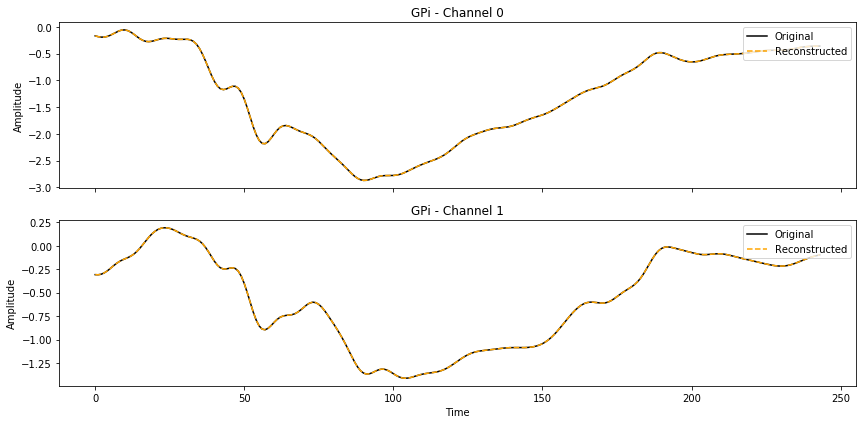

In [ ]:
run_recon_path = r"F:\comp_project\MMVAE_run_R"
runPath = os.path.join(run_recon_path, subj)
os.makedirs(runPath, exist_ok=True)
plot_timeseries_reconstruction(model_all, gpi_train_off, stn_train_off, device,
                                   modality='gpi', sample_idx=0, channels_to_plot=[0, 1],
                                   runPath=runPath, epoch=0)

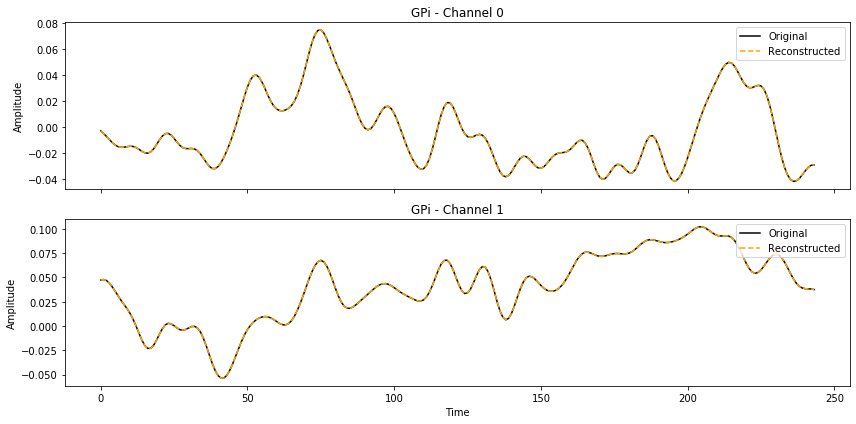

In [17]:
val_iter = iter(val_loader)
gpi_val, stn_val = next(val_iter)
plot_timeseries_reconstruction(model_all, gpi_val, stn_val, device,
                                   modality='gpi', sample_idx=0, channels_to_plot=[0, 1],
                                   runPath=runPath, epoch=40)

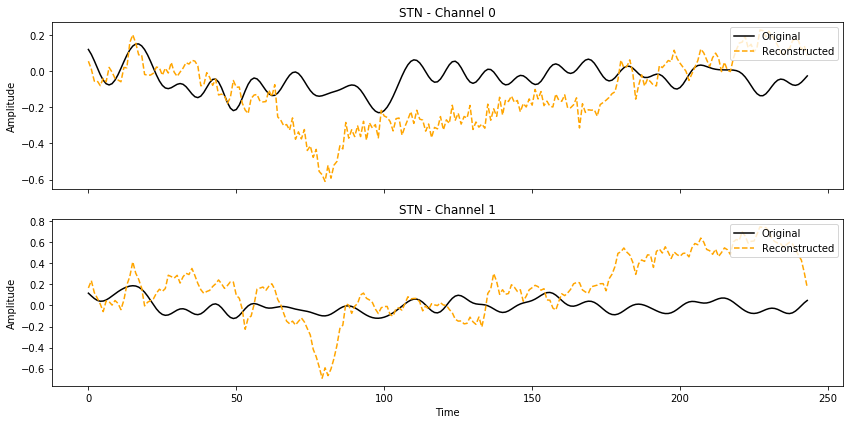

In [18]:
val_iter = iter(val_loader)
gpi_val, stn_val = next(val_iter)
plot_timeseries_reconstruction(model_all, gpi_val, stn_val, device,
                                   modality='stn', sample_idx=0, channels_to_plot=[0, 1],
                                   runPath=runPath, epoch=40)

Epoch 1: Train Loss = 51067.65, Val Loss = 44580.24
Epoch 2: Train Loss = 48826.48, Val Loss = 43350.40
Epoch 3: Train Loss = 47652.97, Val Loss = 42911.33
Epoch 4: Train Loss = 46787.14, Val Loss = 41379.11
Epoch 5: Train Loss = 46215.75, Val Loss = 41046.73
Epoch 6: Train Loss = 46172.13, Val Loss = 41097.60
Epoch 7: Train Loss = 45895.16, Val Loss = 41010.41
Epoch 8: Train Loss = 45840.87, Val Loss = 40906.19
Epoch 9: Train Loss = 45840.39, Val Loss = 41037.25
Epoch 10: Train Loss = 45714.73, Val Loss = 40792.21
Epoch 11: Train Loss = 45627.46, Val Loss = 40595.81
Epoch 12: Train Loss = 45473.69, Val Loss = 41414.33
Epoch 13: Train Loss = 45231.91, Val Loss = 40563.79
Epoch 14: Train Loss = 45167.60, Val Loss = 40809.52
Epoch 15: Train Loss = 45298.60, Val Loss = 40102.76
Epoch 16: Train Loss = 44734.98, Val Loss = 40350.06
Epoch 17: Train Loss = 44398.67, Val Loss = 40180.62
Epoch 18: Train Loss = 44420.75, Val Loss = 40155.80
Epoch 19: Train Loss = 44146.80, Val Loss = 39163.02
Ep

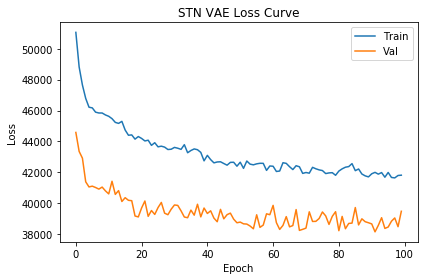

In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from models.vae_lfp import LFPVAE
from objectives import elbo
import matplotlib.pyplot as plt

# Settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 8
batch_size = 8
num_epochs = 100

# Load & preprocess STN data
data_path = r"F:\comp_project\Off_tensor_Data_R\s508\stn_train_off.pt"
stn_data = torch.load(data_path)[:, :244, :].permute(0, 2, 1)
stn_data = (stn_data - stn_data.mean()) / stn_data.std()
input_length = stn_data.shape[2]
stn_channels = stn_data.shape[1]
# Data loaders
dataset = TensorDataset(stn_data)
train_set, val_set = random_split(dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)

# Model
class Params:
    def __init__(self, input_channels, input_length, latent_dim, learn_prior=False):
        self.input_channels = input_channels
        self.input_length = input_length
        self.latent_dim = latent_dim
        self.learn_prior = learn_prior
        self.name = "stn_vae"

params = Params(input_channels=stn_channels, input_length=input_length, latent_dim=latent_dim)
model = LFPVAE(params).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    total_train = 0
    for xb, in train_loader:
        xb = xb.to(device)
        loss = -elbo(model, xb, K=5)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train += loss.item()
    train_losses.append(total_train / len(train_loader))

    model.eval()
    with torch.no_grad():
        val_loss = sum([-elbo(model, xb.to(device), K=5).item() for xb, in val_loader]) / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {train_losses[-1]:.2f}, Val Loss = {val_losses[-1]:.2f}")

# Plot
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title("STN VAE Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()


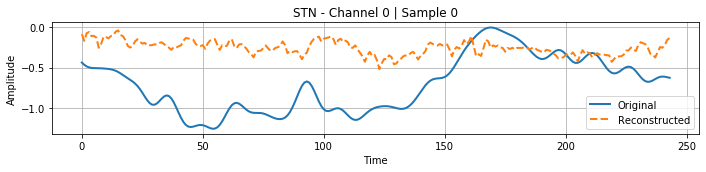

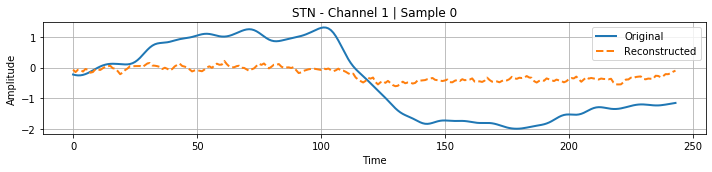

In [8]:
plot_stn_reconstruction_timeseries(model, stn_tensor=stn_train_off, device=device, sample_idx=0, channels_to_plot=[0, 1])
